# Calcium simulation and OASIS deconvolution demo

This notebook demonstrates a simple calcium-imaging simulation pipeline:

1. simulate spatially tuned spikes from a linear track,
2. transform spikes into noisy calcium traces,
3. deconvolve the traces with OASIS,
4. compare ground-truth spikes, calcium, and inferred spikes across run and replay conditions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from oasis.functions import deconvolve

from replay_trajectory_classification.simulate_calcium import (
    make_continuous_replay,
    make_hover_replay,
    make_simulated_run_data,
    make_theta_sweep,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:13: UserWarning: Could not find cvxpy. Don't worry, you can still use OASIS, just not the slower interior point methods we compared to in the papers.
  warn("Could not find cvxpy. Don't worry, you can still use OASIS, " +
Cupy is not installed or GPU is not detected. Ignore this message if not using GPU
I0000 00:00:1779070302.263835  474022 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779070302.592934  474022 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779070303.734857  474022 

Instructions for updating:
non-resource variables are not supported in the long term


/home/ericliu/anaconda3/lib/python3.13/site-packages/replay_trajectory_classification/likelihoods/multiunit_likelihood.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
RNG_SEED = 42
TRACK_HEIGHT = 180.0
N_NEURONS = 20
PLACE_FIELD_MEANS = np.linspace(0.0, TRACK_HEIGHT, N_NEURONS)
RUNNING_SPEED = 10.0
SIGMA = 1.0
N_RUNS = 2
REPLAY_SAMPLING_FREQUENCY = 200
REPLAY_SWEEPS = 6
HOVER_NEURON_IND = N_NEURONS // 2
NEURON_IND = N_NEURONS // 2

In [3]:
def deconvolve_calcium_traces(calcium_traces):
    calcium_traces = np.asarray(calcium_traces, dtype=float)
    if calcium_traces.ndim == 1:
        calcium_traces = calcium_traces[:, np.newaxis]

    T = calcium_traces.shape[0]
    shift = min(100, max(1, T // 2))

    deconvolved = np.zeros_like(calcium_traces)
    for neuron_ind in range(calcium_traces.shape[1]):
        _, spikes, _, _, _ = deconvolve(
            calcium_traces[:, neuron_ind],
            g=(None, None),
            penalty=1,
            shift=shift,
        )
        deconvolved[:, neuron_ind] = np.asarray(spikes)
    return deconvolved


def plot_raster(ax, time, true_spikes):
    spike_times = [time[true_spikes[:, ind] > 0] for ind in range(true_spikes.shape[1])]
    ax.eventplot(spike_times, colors="black", linewidths=0.8)
    ax.set_ylabel("Neuron")
    ax.set_ylim(-0.5, true_spikes.shape[1] - 0.5)


def plot_stacked_signals(ax, time, calcium_traces, deconvolved_spikes):
    calcium_span = float(np.nanmax(calcium_traces) - np.nanmin(calcium_traces))
    deconv_span = float(np.nanmax(deconvolved_spikes))
    offset_step = max(1.0, calcium_span + deconv_span + 0.25)
    offsets = np.arange(calcium_traces.shape[1]) * offset_step

    for neuron_ind, offset in enumerate(offsets):
        ax.plot(time, calcium_traces[:, neuron_ind] + offset, color="black", lw=0.8)
        spike_mask = deconvolved_spikes[:, neuron_ind] > 0
        if np.any(spike_mask):
            ax.vlines(
                time[spike_mask],
                offset,
                offset + deconvolved_spikes[spike_mask, neuron_ind],
                color="tab:red",
                lw=0.9,
                alpha=0.9,
            )

    ax.set_yticks(offsets)
    ax.set_yticklabels(np.arange(1, calcium_traces.shape[1] + 1))
    ax.set_ylabel("Neuron")


def plot_population_view(time, true_spikes, calcium_traces, deconvolved_spikes, title, position=None):
    n_rows = 3 if position is not None else 2
    height_ratios = [1.2, 1.0, 4.5] if position is not None else [1.0, 4.5]
    fig, axes = plt.subplots(
        n_rows,
        1,
        figsize=(14, 2.2 * n_rows + 0.18 * calcium_traces.shape[1]),
        sharex=True,
        constrained_layout=True,
        gridspec_kw={"height_ratios": height_ratios},
    )

    if position is not None:
        axes[0].plot(time, position, color="tab:blue", lw=1.2)
        axes[0].set_ylabel("Position\n(cm)")
        plot_raster(axes[1], time, true_spikes)
        plot_stacked_signals(axes[2], time, calcium_traces, deconvolved_spikes)
        axes[2].set_xlabel("Time (s)")
    else:
        plot_raster(axes[0], time, true_spikes)
        plot_stacked_signals(axes[1], time, calcium_traces, deconvolved_spikes)
        axes[1].set_xlabel("Time (s)")

    fig.suptitle(title)
    return fig, axes


def plot_single_neuron_comparison(datasets, neuron_ind, title):
    fig, axes = plt.subplots(
        2,
        len(datasets),
        figsize=(4.6 * len(datasets), 5.2),
        sharex="col",
        constrained_layout=True,
    )

    for col_ind, dataset in enumerate(datasets):
        time = dataset["time"]
        calcium = dataset["calcium"][:, neuron_ind]
        true_spikes = dataset["true_spikes"][:, neuron_ind]
        deconvolved = dataset["deconvolved"][:, neuron_ind]

        calcium_ax = axes[0, col_ind]
        deconv_ax = axes[1, col_ind]

        calcium_ax.plot(time, calcium, color="black", lw=1.0)
        spike_mask = true_spikes > 0
        signal_span = max(0.1, float(np.ptp(calcium)))
        tick_height = 0.15 * signal_span
        tick_base = float(np.min(calcium) - 1.3 * tick_height)
        if np.any(spike_mask):
            calcium_ax.vlines(
                time[spike_mask],
                tick_base,
                tick_base + tick_height,
                color="tab:blue",
                lw=1.1,
            )
        calcium_ax.set_ylim(tick_base - 0.2 * tick_height, np.max(calcium) + tick_height)
        calcium_ax.set_title(dataset["label"])

        deconv_mask = deconvolved > 0
        if np.any(deconv_mask):
            deconv_ax.vlines(
                time[deconv_mask],
                0.0,
                deconvolved[deconv_mask],
                color="tab:red",
                lw=1.2,
            )
        deconv_ax.set_ylim(0.0, max(0.1, 1.05 * float(np.max(deconvolved))))
        deconv_ax.set_xlabel("Time (s)")

        if col_ind == 0:
            calcium_ax.set_ylabel("Calcium")
            deconv_ax.set_ylabel("OASIS\nspikes")

    fig.suptitle(title)
    return fig, axes

## Section 1a: noise comparison for one neuron

/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],


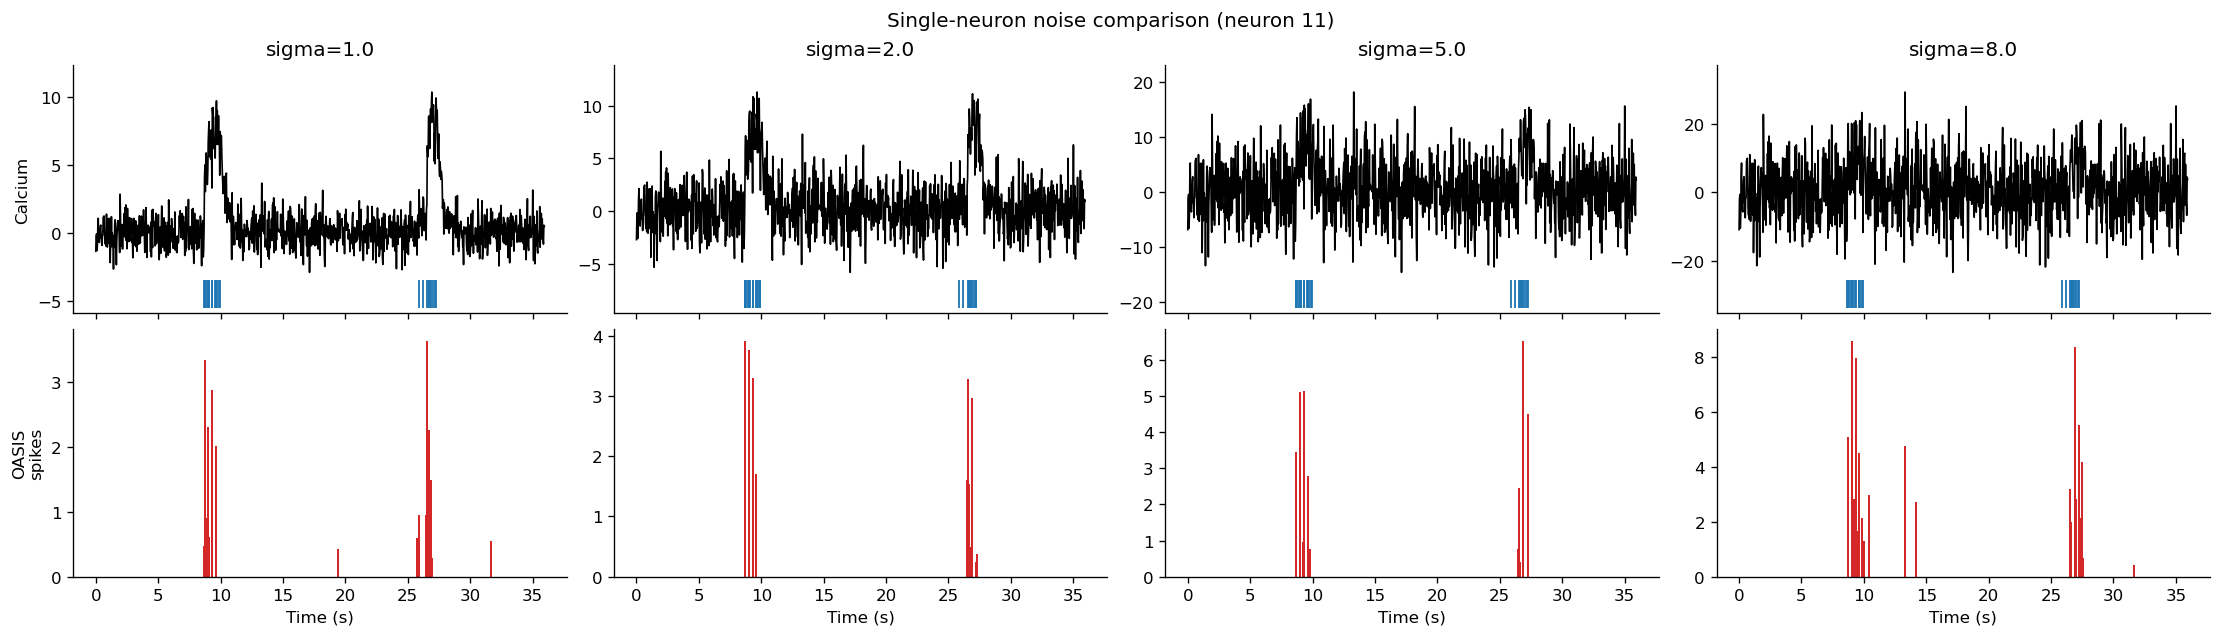

In [4]:
noise_datasets = []
for sigma in [1.0, 2.0, 5.0, 8.0]:
    time, _, _, calcium_traces, true_spikes, _ = make_simulated_run_data(
        running_speed=RUNNING_SPEED,
        track_height=TRACK_HEIGHT,
        n_runs=1,
        place_field_means=PLACE_FIELD_MEANS,
        sigma=sigma,
        rng=np.random.default_rng(RNG_SEED),
    )
    deconvolved_spikes = deconvolve_calcium_traces(calcium_traces[:, [NEURON_IND]])
    noise_datasets.append(
        {
            "label": f"sigma={sigma}",
            "time": time,
            "calcium": calcium_traces[:, [NEURON_IND]],
            "true_spikes": true_spikes[:, [NEURON_IND]],
            "deconvolved": deconvolved_spikes,
        }
    )

plot_single_neuron_comparison(
    noise_datasets,
    neuron_ind=0,
    title=f"Single-neuron noise comparison (neuron {NEURON_IND + 1})",
);

## Section 1b: running-speed comparison for one neuron

/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 181, using nperseg = 181
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


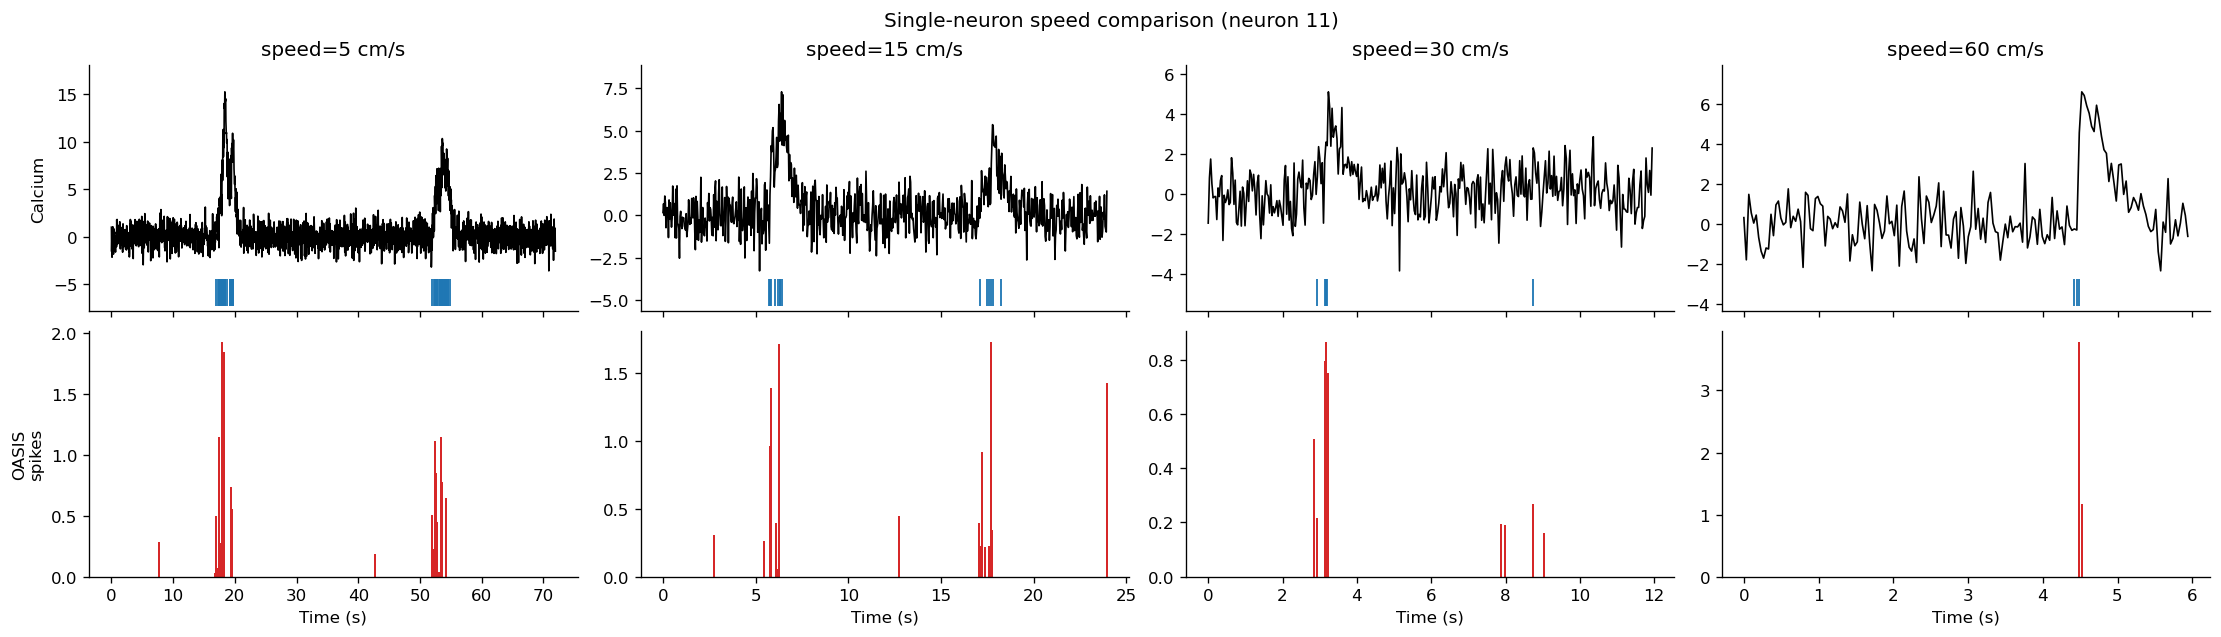

In [5]:
speed_datasets = []
for running_speed in [5.0, 15.0, 30.0, 60.0]:
    time, _, _, calcium_traces, true_spikes, _ = make_simulated_run_data(
        running_speed=running_speed,
        track_height=TRACK_HEIGHT,
        n_runs=1,
        place_field_means=PLACE_FIELD_MEANS,
        sigma=SIGMA,
        rng=np.random.default_rng(RNG_SEED),
    )
    deconvolved_spikes = deconvolve_calcium_traces(calcium_traces[:, [NEURON_IND]])
    speed_datasets.append(
        {
            "label": f"speed={running_speed:.0f} cm/s",
            "time": time,
            "calcium": calcium_traces[:, [NEURON_IND]],
            "true_spikes": true_spikes[:, [NEURON_IND]],
            "deconvolved": deconvolved_spikes,
        }
    )

plot_single_neuron_comparison(
    speed_datasets,
    neuron_ind=0,
    title=f"Single-neuron speed comparison (neuron {NEURON_IND + 1})",
);

## Section 2: full spatial run

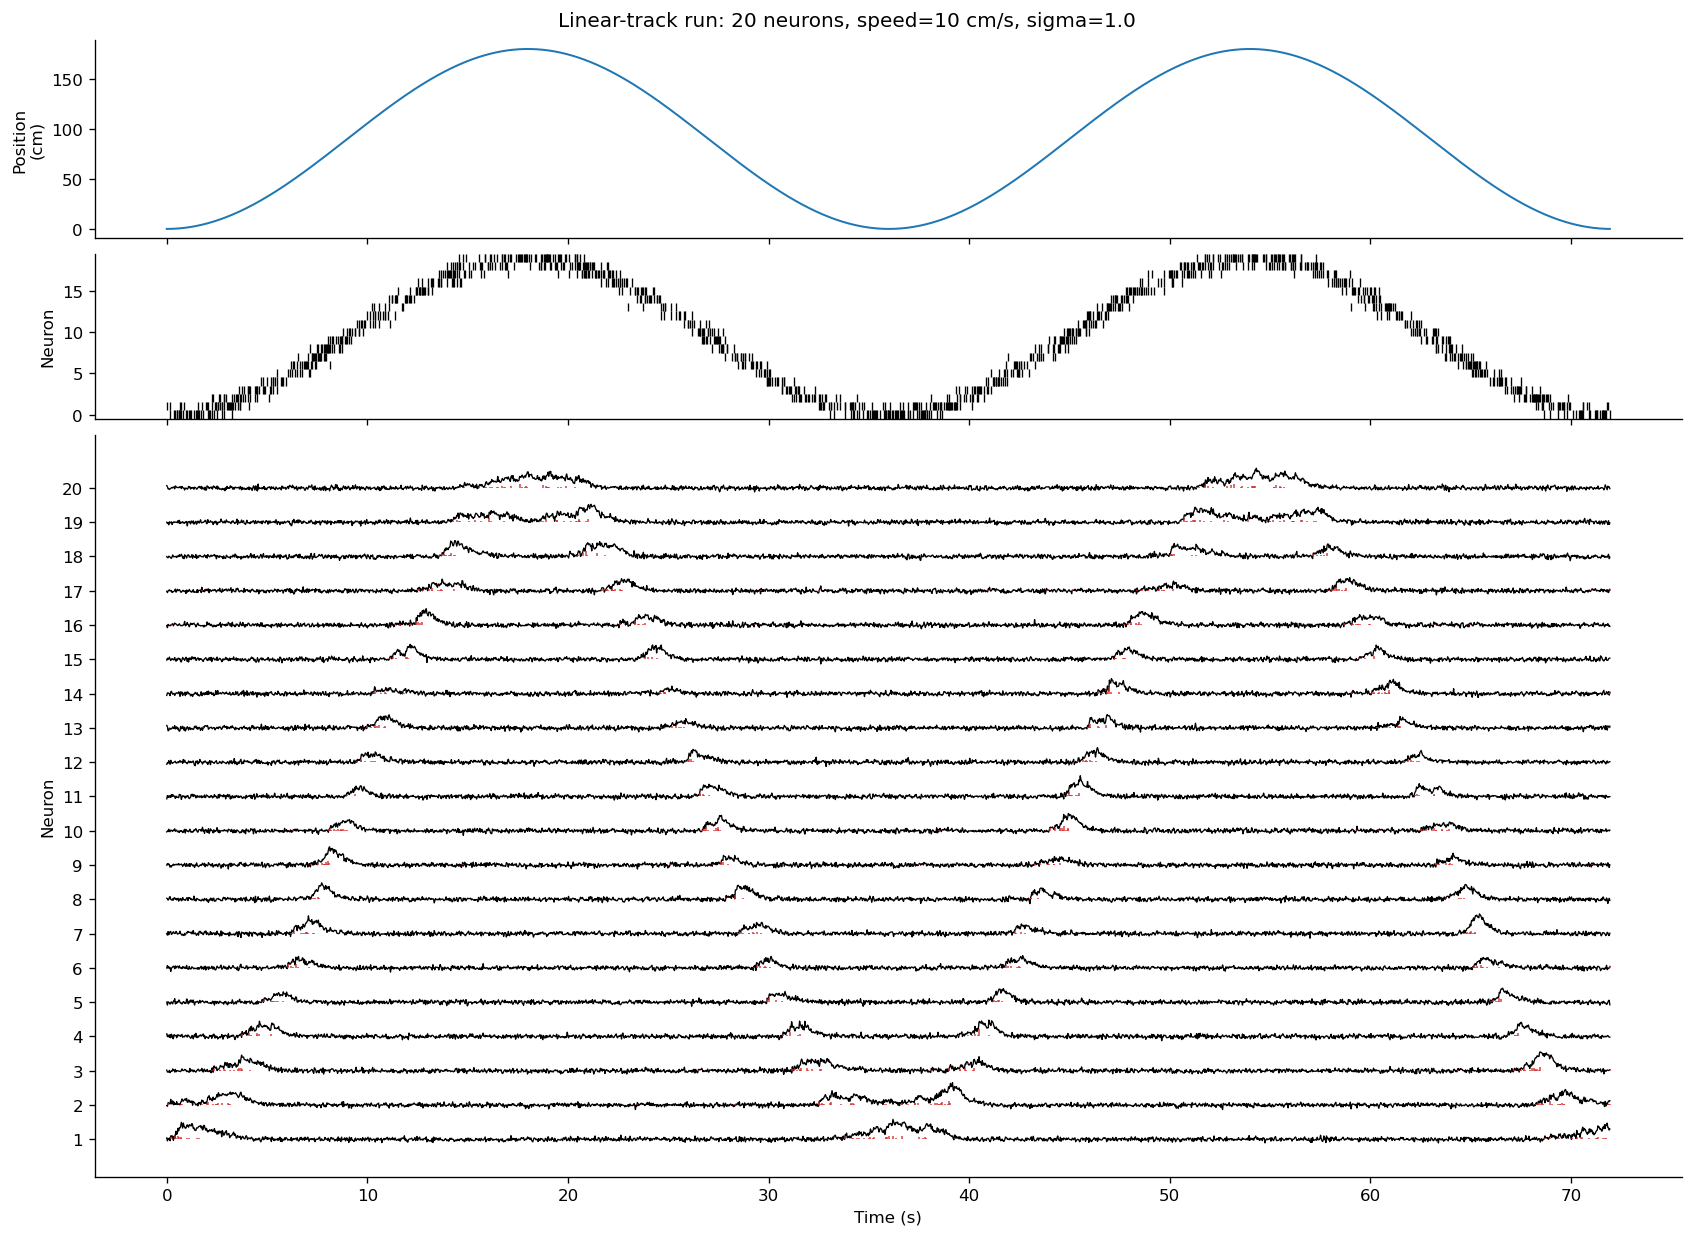

In [6]:
time, position, sampling_frequency, calcium_traces, true_spikes, place_fields = make_simulated_run_data(
    running_speed=RUNNING_SPEED,
    track_height=TRACK_HEIGHT,
    n_runs=N_RUNS,
    place_field_means=PLACE_FIELD_MEANS,
    sigma=SIGMA,
    rng=np.random.default_rng(RNG_SEED),
)
deconvolved_spikes = deconvolve_calcium_traces(calcium_traces)
plot_population_view(
    time,
    true_spikes,
    calcium_traces,
    deconvolved_spikes,
    title=f"Linear-track run: {N_NEURONS} neurons, speed={RUNNING_SPEED:.0f} cm/s, sigma={SIGMA}",
    position=position,
);

## Section 3: replay conditions

Replay events are short, so the output sampling rate is increased here to keep the traces visible.

/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 200, using nperseg = 200
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not `ravel`ed. To preserve the existing behavior and silence this warning, `ravel` arguments before passing them to `toeplitz`.
  A = scipy.linalg.toeplitz(xc[np.arange(lags)],
/home/ericliu/anaconda3/lib/python3.13/site-packages/scipy/signal/_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 90, using nperseg = 90
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
/home/ericliu/anaconda3/lib/python3.13/site-packages/oasis/functions.py:817: FutureWarning: Beginning in SciPy 1.17, multidimensional input will be treated as a batch, not

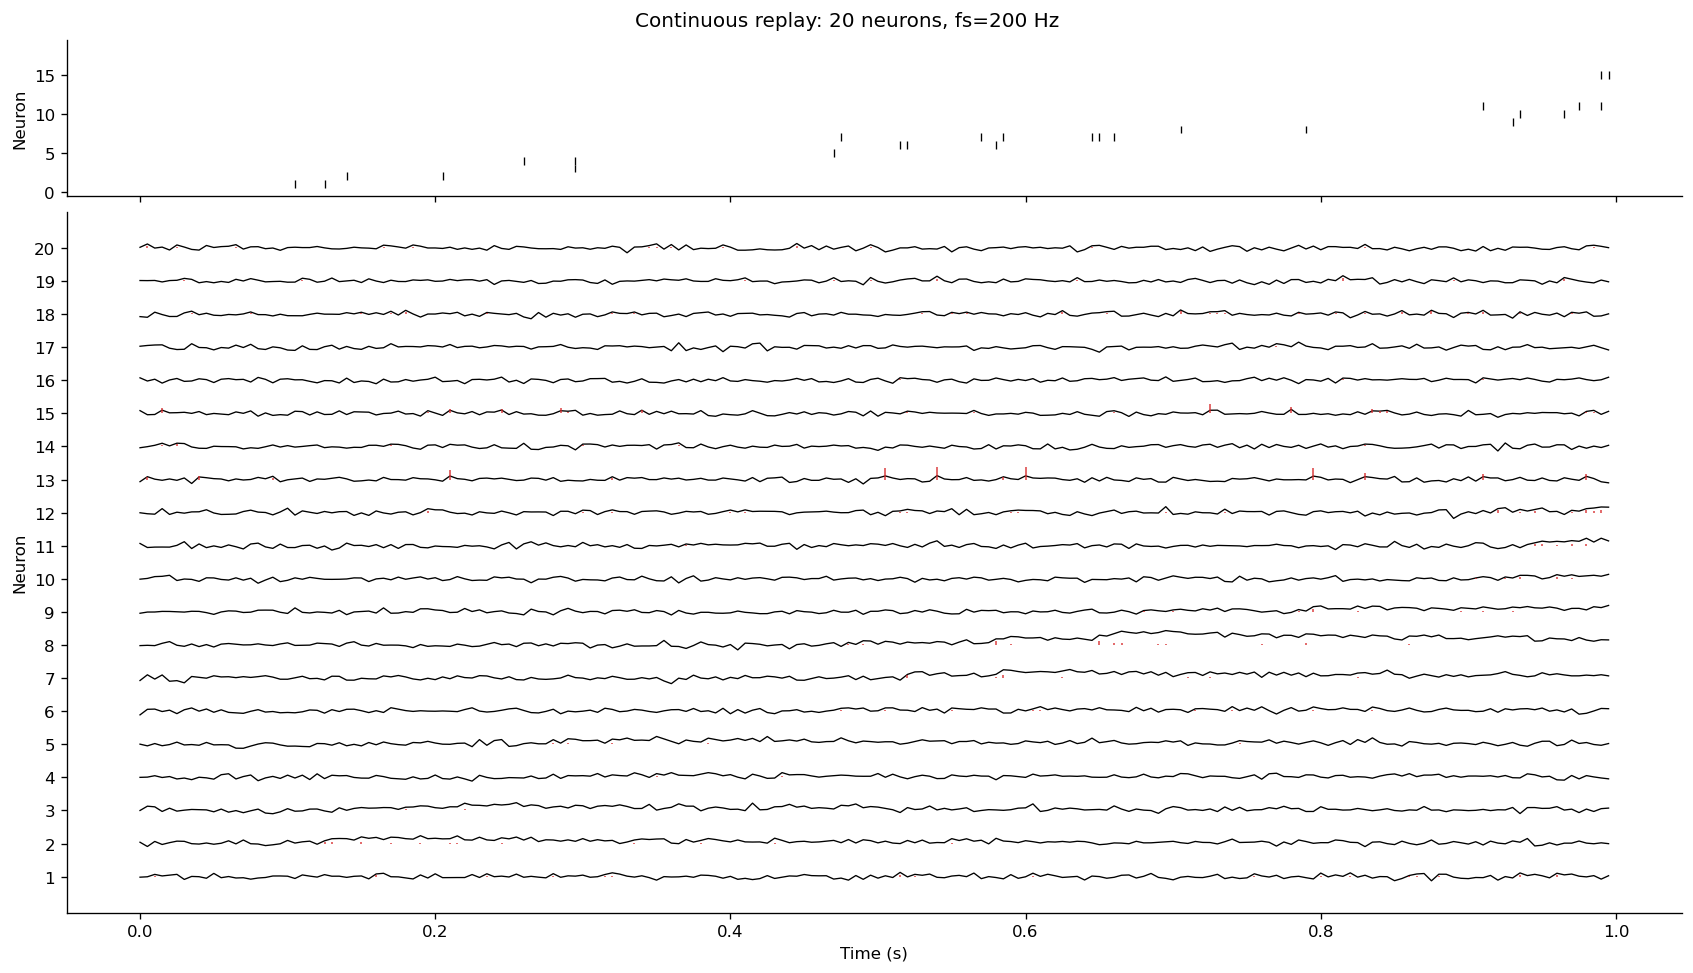

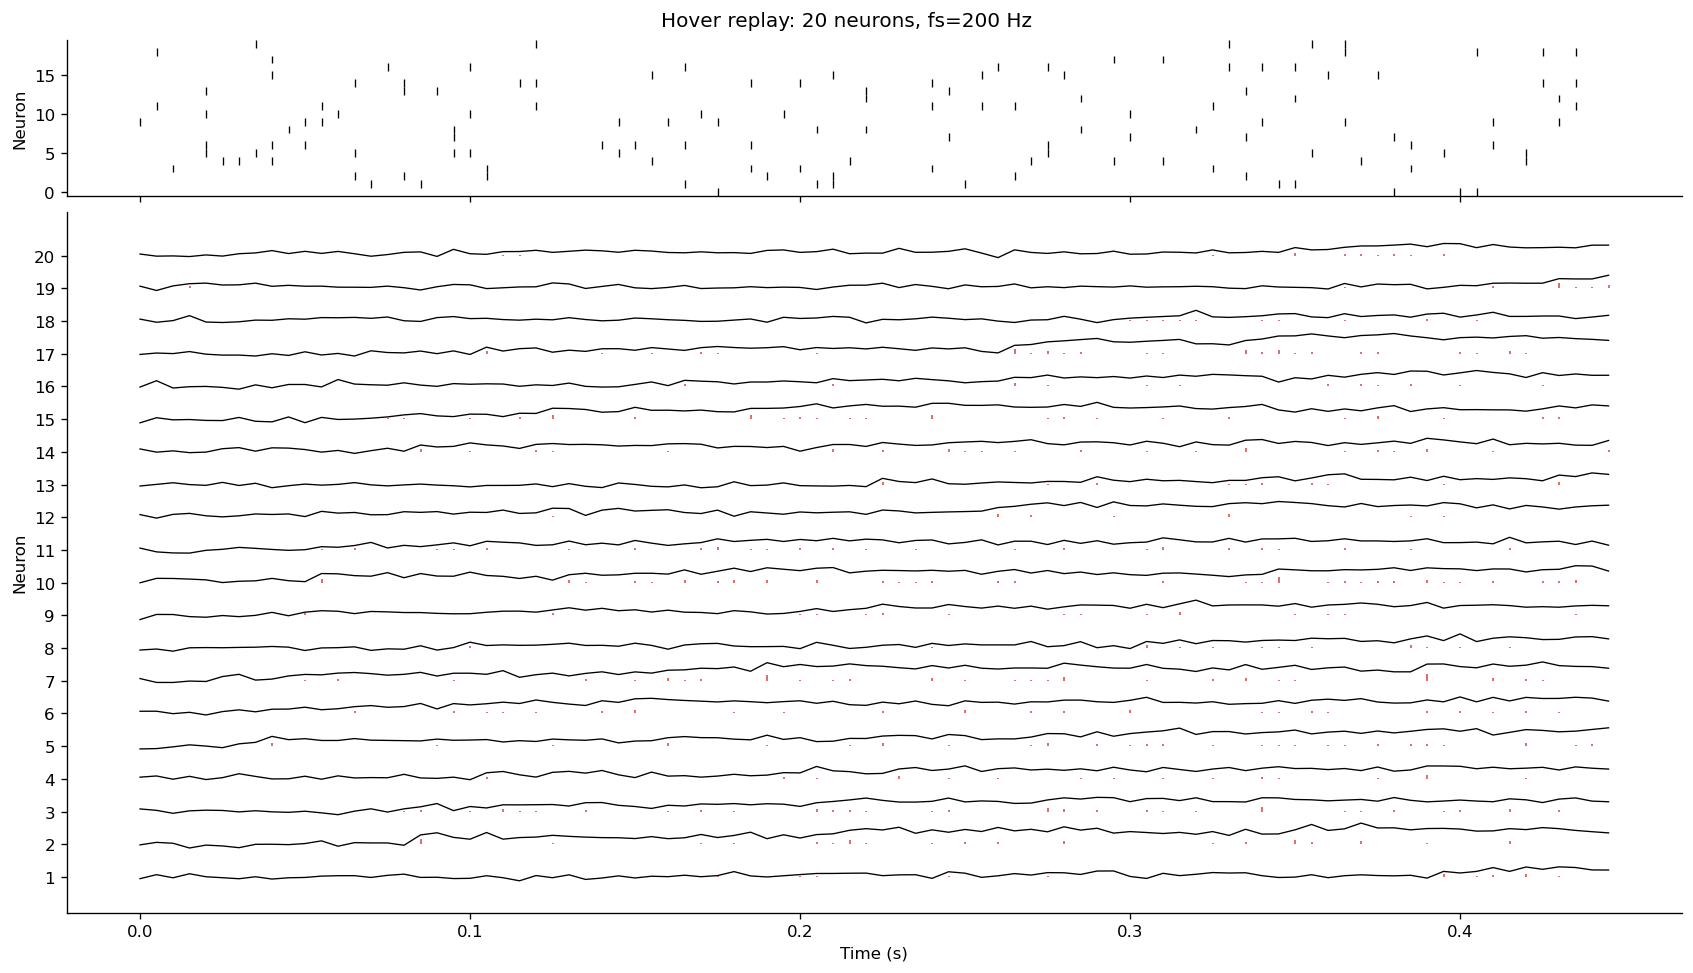

In [7]:
replay_conditions = [
    (
        "Continuous replay",
        make_continuous_replay(
            sampling_frequency=REPLAY_SAMPLING_FREQUENCY,
            running_speed=RUNNING_SPEED,
            track_height=TRACK_HEIGHT,
            place_field_means=PLACE_FIELD_MEANS,
            replay_speedup=10,
            sigma=SIGMA,
            rng=np.random.default_rng(RNG_SEED),
        ),
    ),
    (
        "Hover replay",
        make_hover_replay(
            hover_neuron_ind=HOVER_NEURON_IND,
            place_field_means=PLACE_FIELD_MEANS,
            sampling_frequency=REPLAY_SAMPLING_FREQUENCY,
            sigma=SIGMA,
            rng=np.random.default_rng(RNG_SEED),
        ),
    ),
    # (
    #     "Theta sweep",
    #     make_theta_sweep(
    #         sampling_frequency=REPLAY_SAMPLING_FREQUENCY,
    #         running_speed=RUNNING_SPEED,
    #         track_height=TRACK_HEIGHT,
    #         place_field_means=PLACE_FIELD_MEANS,
    #         replay_speedup=145,
    #         sigma=SIGMA,
    #         n_sweeps=REPLAY_SWEEPS,
    #         rng=np.random.default_rng(RNG_SEED),
    #     ),
    # ),
]

for title, (replay_time, replay_spikes, replay_calcium) in replay_conditions:
    replay_deconvolved = deconvolve_calcium_traces(replay_calcium)
    plot_population_view(
        replay_time,
        replay_spikes,
        replay_calcium,
        replay_deconvolved,
        title=f"{title}: {N_NEURONS} neurons, fs={REPLAY_SAMPLING_FREQUENCY} Hz",
    );